# Model Fitting - Prevalence

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import minimize

from epimodels.continuous.models import SIRSEIData

%matplotlib inline

In [2]:
# Load data
DATA_PATH = './data/'
climate_df = pd.read_csv(f'{DATA_PATH}climate_api_data_2016_2024.csv')
cases_df = pd.read_csv(f'{DATA_PATH}cumulative_manaus_cases_2016_2023.csv')

climate_df['date'] = pd.to_datetime(climate_df['date'])
cases_df['date'] = pd.to_datetime(cases_df['date'])
merged_df = pd.merge(cases_df, climate_df, on='date', how='inner')
merged_df['day_number'] = (merged_df['date'] - merged_df['date'].min()).dt.days

N = 9586
M = 3000

In [3]:
# Climate interpolation
temp_interp = interp1d(merged_df['day_number'], merged_df['temp_med'], 
                     kind='linear', bounds_error=False, fill_value='extrapolate')
precip_interp = interp1d(merged_df['day_number'], merged_df['precip_med'],
                        kind='linear', bounds_error=False, fill_value='extrapolate')

times = merged_df['day_number'].values
observed_prevalence = merged_df['active_total'].values.astype(float)

initial_Ih = float(merged_df['active_total'].iloc[0])
initial_Rh = initial_Ih * 0.3
initial_Sh = N - initial_Ih - initial_Rh
inits = [initial_Sh, initial_Ih, initial_Rh, M*0.99, M*0.009, M*0.001]

print(f"Prevalence: {observed_prevalence.min():.0f} to {observed_prevalence.max():.0f}")

Prevalence: 0 to 4897


In [4]:
# Fixed parameters
fixed_params = {
    'BE': 200, 'tauE': 1, 'tauP': 1, 'D1': 32.5,
    'RL': 32.26, 'mu_H': 0.00004, 'DD': 105, 'Tmin': 14.5,
    'gamma': 1/120,
}

# Parameters to fit
x0 = [21.6, 0.9, 0.25, 0.75, 0.01, 0.1, 0.4, 0.5, 0.01, 1.0, 0.1]
bounds = [
    (15.0, 30.0),    (0.5, 0.99),    (0.1, 0.5),    (0.5, 0.9),
    (0.001, 0.2),    (0.001, 0.5),   (0.1, 0.9),    (0.3, 0.9),
    (0.001, 10.0),   (0.001, 5.0),   (0.001, 20.0),
]
param_names = ['T_prime', 'pME', 'pML', 'pMP', 'c1', 'c2', 'b1', 'b2', 'A', 'B', 'C']

In [5]:
def loss(x, times, obs_prev, N, M, fixed, inits, param_names):
    params = {**fixed}
    for name, val in zip(param_names, x):
        params[name] = val
    
    model = SIRSEIData(temp_interp, precip_interp)
    try:
        model(inits=inits, trange=[times.min(), times.max()], totpop=N+M, params=params, validate=False)
    except:
        return 1e10
    
    fitted = np.interp(times, model.traces['time'], model.traces['Ih'])
    if np.any(np.isnan(fitted)) or np.any(np.isinf(fitted)):
        return 1e10
    
    return np.sum((obs_prev - fitted)**2)

In [6]:
print("Running optimization...")
result = minimize(loss, x0, args=(times, observed_prevalence, N, M, fixed_params, inits, param_names),
                 method='Nelder-Mead', options={'maxiter': 300, 'xatol': 1e-3, 'fatol': 1e5})

fitted_params = dict(zip(param_names, result.x))
print(f"Success: {result.success}, Loss: {result.fun:.2f}, Iterations: {result.nit}")
for k, v in fitted_params.items():
    print(f"  {k}: {v:.6f}")

Running optimization...
Success: False, Loss: 8378153228.64, Iterations: 300
  T_prime: -327.921056
  pME: 2.097075
  pML: 1.687509
  pMP: 1.783083
  c1: -0.005267
  c2: 0.246855
  b1: 1.454731
  b2: 0.002973
  A: 0.035536
  B: 5.871342
  C: 0.054134


In [7]:
final_params = {**fixed_params, **fitted_params}
fitted_model = SIRSEIData(temp_interp, precip_interp)
fitted_model(inits=inits, trange=[times.min(), times.max()], totpop=N+M, params=final_params, validate=False)

fitted_Ih = np.interp(times, fitted_model.traces['time'], fitted_model.traces['Ih'])
dates = merged_df['date'].values

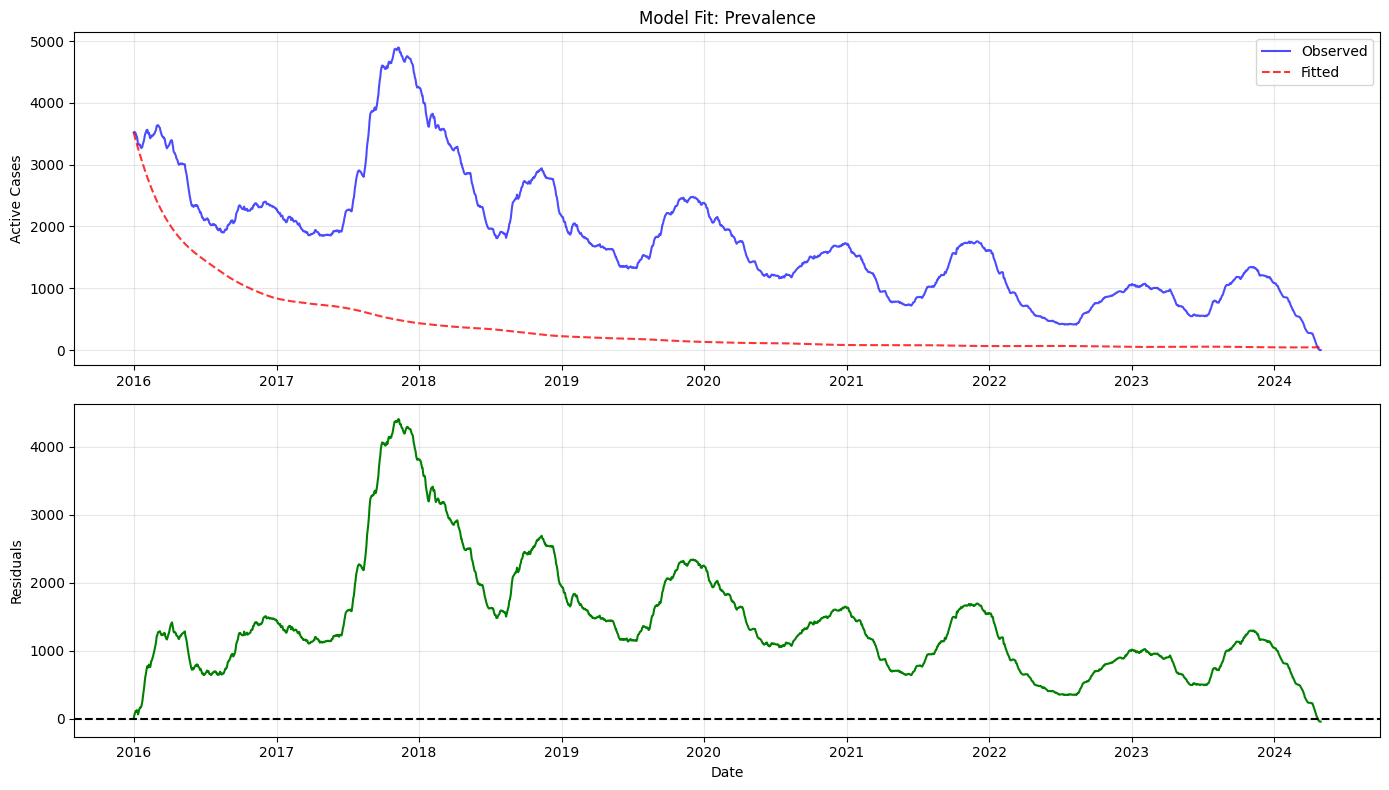

RMSE: 1659.57


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(dates, observed_prevalence, 'b-', alpha=0.7, label='Observed')
axes[0].plot(dates, fitted_Ih, 'r--', alpha=0.8, label='Fitted')
axes[0].set_ylabel('Active Cases')
axes[0].set_title('Model Fit: Prevalence')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals = observed_prevalence - fitted_Ih
axes[1].plot(dates, residuals, 'g-')
axes[1].axhline(y=0, color='k', linestyle='--')
axes[1].set_ylabel('Residuals')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"RMSE: {np.sqrt(np.mean(residuals**2)):.2f}")